In [1]:
import scanpy as sc
import harmonypy as hm
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15880/1588021508.py:7: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, frameon=False)


## Load and subset

In [2]:
adata = sc.read_h5ad('inputs/anndatas/omentum_reannotated_finely.h5ad')
adata

AnnData object with n_obs × n_vars = 25830 × 26158
    obs: 'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant'
    v

In [3]:
sub = adata[adata.obs['cell_type2_'] == 'Macrophages'].copy()
print(f"Macrophages: {sub.n_obs} cells")
print(sub.obs[['cell_type_', 'cell_type2_', 'cohort', 'common_participant']].value_counts(['cohort']).to_string())
sub

Macrophages: 811 cells
cohort   
Healthy      424
Unhealthy    387


AnnData object with n_obs × n_vars = 811 × 26158
    obs: 'status', 'assignment', 'singlet_posterior', 'doublet_posterior', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'cluster4', 'sample_name', 'disease', 'tissue', 'cohort', 'participant', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'leiden_res_0.02', 'leiden_res_0.20', 'leiden_res_0.30', 'leiden_res_0.40', 'leiden_res_0.50', 'leiden_res_0.60', 'leiden_res_1.00', 'cell_type', 'cd45', 'cell_type1', 'scrublet_score', 'scrublet_call', 'lib_name', 'sex', 'cell_type_', 'cell_type1_', 'cell_type2_', 'common_participant'
    var

## Preprocess from raw counts

In [4]:
sub.X = sub.layers['counts'].copy()

sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

sc.pp.highly_variable_genes(sub, n_top_genes=1000, flavor='seurat_v3', layer='counts')
print(f"Highly variable genes: {sub.var.highly_variable.sum()}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Highly variable genes: 1000


## PCA

/opt/miniconda3/envs/rnaseq/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15880/2214184102.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.tl.pca(sub, n_comps=10, use_highly_variable=True)


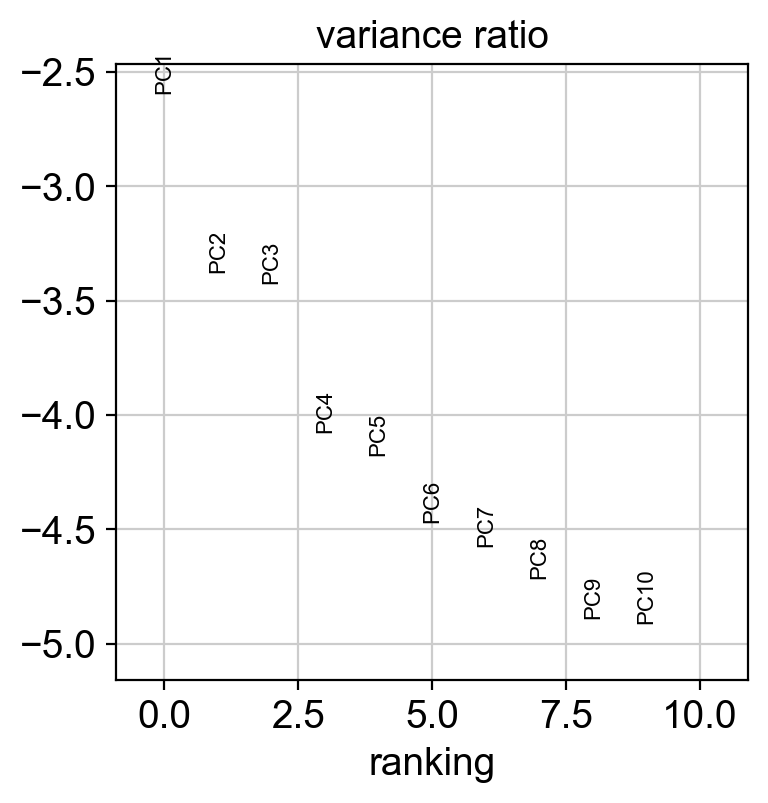

In [5]:
sc.pp.scale(sub, max_value=10)
sc.tl.pca(sub, n_comps=10, use_highly_variable=True)
sc.pl.pca_variance_ratio(sub, n_pcs=10, log=True)

## Harmony integration on `common_participant`

In [6]:
ho = hm.run_harmony(
    sub.obsm['X_pca'],
    sub.obs,
    vars_use='common_participant',
    max_iter_harmony=30,
    random_state=42
)
sub.obsm['X_pca_harmony'] = ho.Z_corr
print('Harmony done, shape:', sub.obsm['X_pca_harmony'].shape)

2026-05-10 16:30:05,128 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-05-10 16:30:05,129 - harmonypy - INFO -   Parameters:
2026-05-10 16:30:05,130 - harmonypy - INFO -     max_iter_harmony: 30
2026-05-10 16:30:05,131 - harmonypy - INFO -     max_iter_kmeans: 20
2026-05-10 16:30:05,132 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-05-10 16:30:05,133 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-05-10 16:30:05,134 - harmonypy - INFO -     nclust: 27
2026-05-10 16:30:05,135 - harmonypy - INFO -     block_size: 0.05
2026-05-10 16:30:05,136 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-05-10 16:30:05,137 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-10 16:30:05,137 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-10 16:30:05,138 - harmonypy - INFO -     verbose: True
2026-05-10 16:30:05,139 - harmonypy - INFO -     random_state: 42
2026-05-10 16:30:05,140 - harmonypy - INFO -   Data: 10 PCs × 811 ce

Harmony done, shape: (811, 10)


## Neighbor graph, Leiden clustering, and UMAP

In [7]:
sc.pp.neighbors(sub, use_rep='X_pca_harmony', n_neighbors=10, n_pcs=10)
sc.tl.leiden(sub, resolution=0.4, key_added='leiden_harmony')
sc.tl.umap(sub, min_dist=0.3, random_state=42)

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15880/616510380.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(sub, resolution=0.4, key_added='leiden_harmony')


## UMAP plots

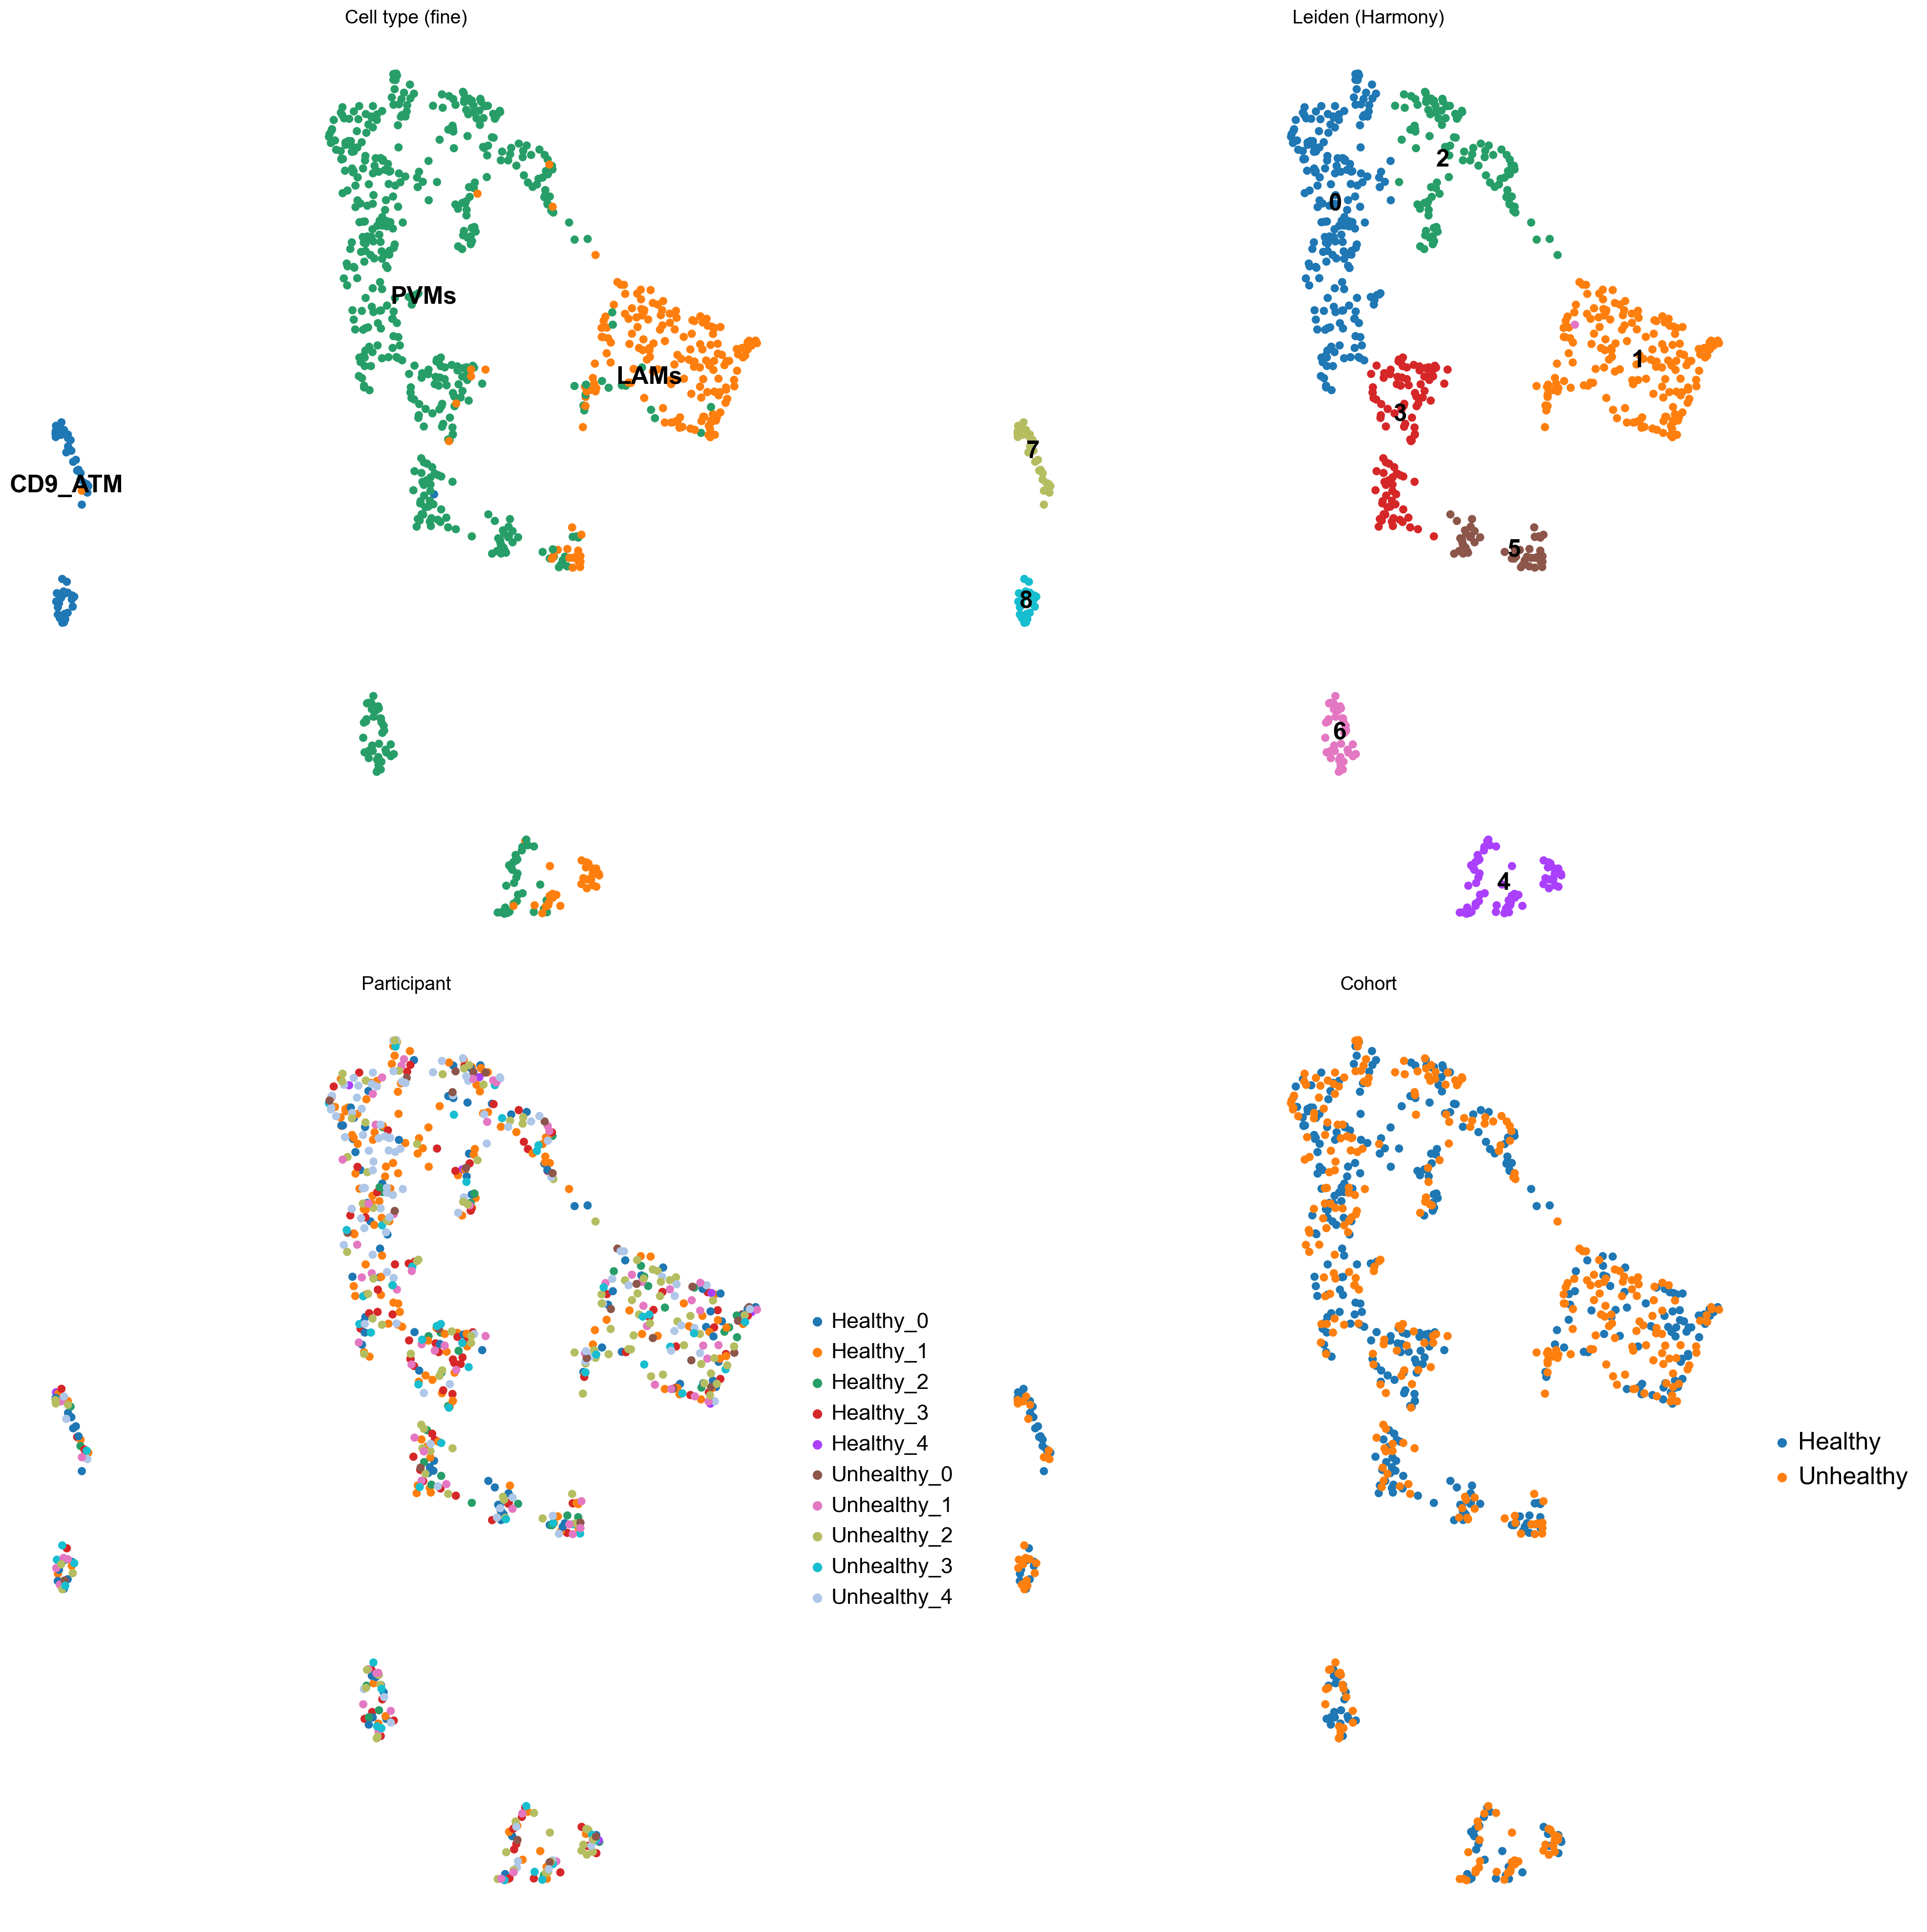

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

sc.pl.umap(sub, color='cell_type1_',     title='Cell type (fine)',    ax=axes[0, 0], show=False, legend_loc='on data', legend_fontsize=18)
sc.pl.umap(sub, color='leiden_harmony',  title='Leiden (Harmony)',    ax=axes[0, 1], show=False, legend_loc='on data', legend_fontsize=18)
sc.pl.umap(sub, color='common_participant', title='Participant',       ax=axes[1, 0], show=False, legend_fontsize=16)
sc.pl.umap(sub, color='cohort',          title='Cohort',              ax=axes[1, 1], show=False, legend_fontsize=18)

plt.tight_layout()
plt.savefig('figures/macrophage_harmony_umap.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_15880/191665086.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub.obs.groupby(['leiden_harmony', 'cohort'])


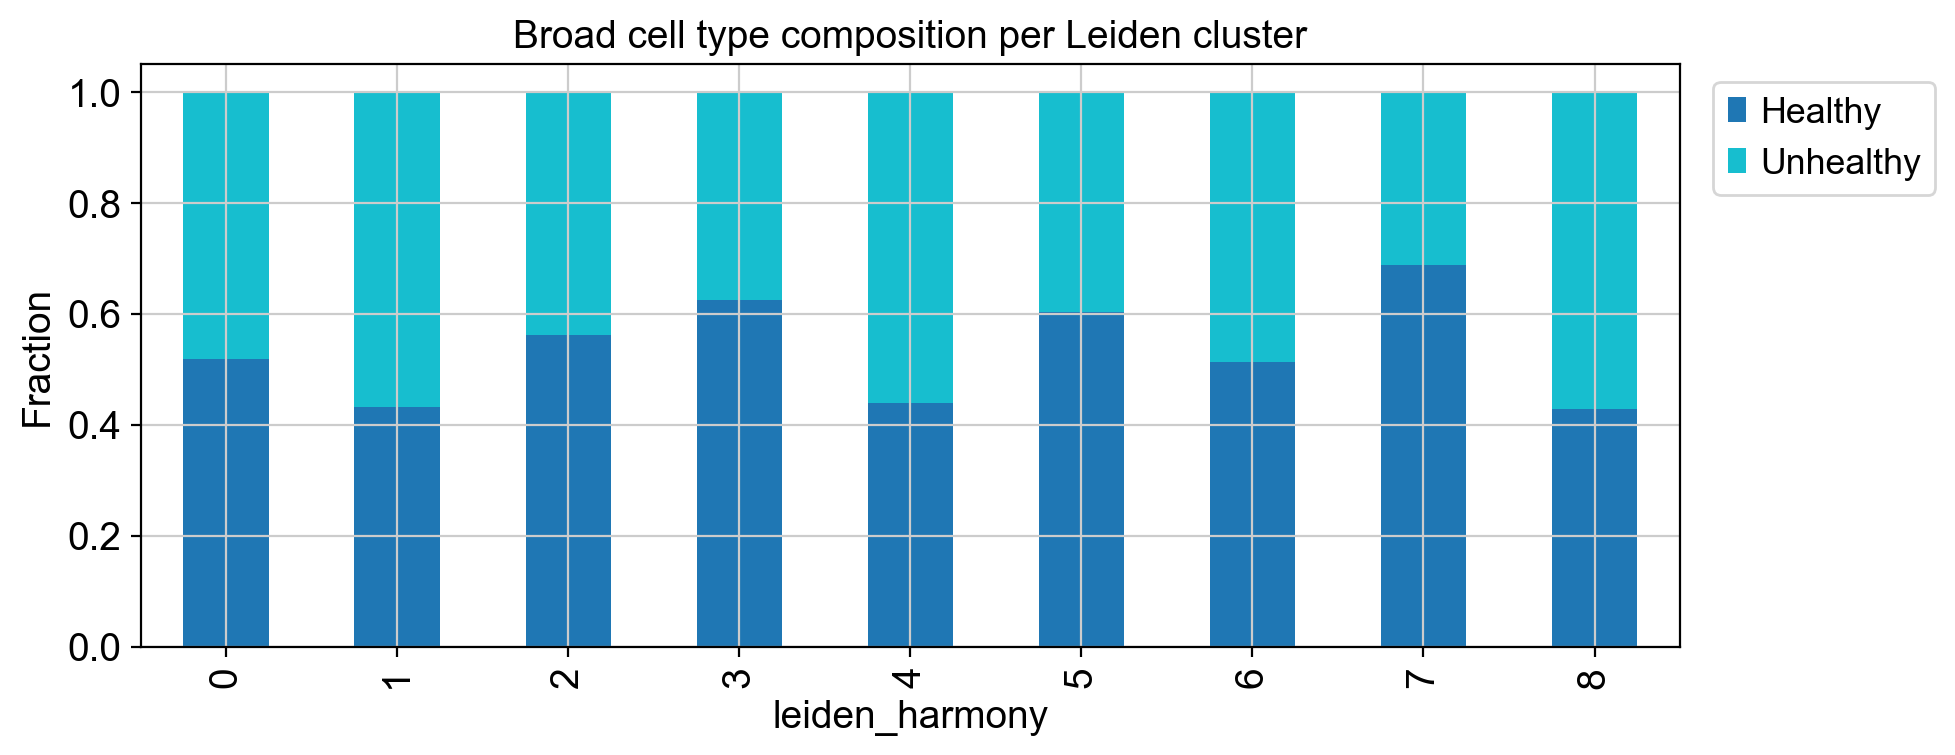

In [12]:
# Cluster composition by broader cell_type_
cluster_ct = (
    sub.obs.groupby(['leiden_harmony', 'cohort'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
cluster_ct.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab10')
plt.ylabel('Fraction')
plt.title('Broad cell type composition per Leiden cluster')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figures/macrophage_harmony_cluster_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print(sub.obs['leiden_harmony'].value_counts().sort_index())

leiden_harmony
0    206
1    178
2    112
3    104
4     66
5     53
6     39
7     32
8     21
Name: count, dtype: int64
